# 20_异常值处理方法-IQR（四分位距）法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这个小节，咱们来详细的介绍异常值处理方法之IQR（四分位距）法。

### 什么是异常值？

在一组数据中，如果某些数特别大或者特别小，和其他大部分数差得很远，我们就叫它“**异常值**”或者“离群值”。

**打个比方：**

假设一个班的同学数学成绩如下：`70, 72, 75, 77, 78, 79, 80, 81, 83, 85, 90, 92, 150`。

这组数据中，150分明显比其他的数大很多，这个“150”就可能是个**异常值**。

### 什么是 IQR（四分位距）？

IQR 叫做“**四分位距**”，是用来描述数据中间部分的一个**跨度范围**。它能帮我们判断数据是不是偏离了“正常”的范围。

我们先要知道几个关键名词：

| 名词 | 说明 |
|-|-|
| Q1（第一四分位数） | 数据中 25% 的位置的数（比它小的数占25%） |
| Q3（第三四分位数） | 数据中 75% 的位置的数（比它小的数占75%） |
| IQR（四分位距） | Q3 - Q1，表示中间一半数据的跨度 |

**用四分位数的好处**：不容易受到极端值的影响。

### IQR法是怎么判断异常值的？

IQR法用一个“盒子”框住中间的数据，然后在盒子的两边各加一个“胡须”，超过胡须的点，就是“异常值”。

**异常值的判断规则如下：**

- **下限 = Q1 - 1.5 × IQR**
- **上限 = Q3 + 1.5 × IQR**

超过这个范围的数，就叫“异常值”。

## 核心原理

### 四分位数的计算（Q1、Q2、Q3）

假设我们有一个升序排列好的数据集合：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
X = [x₁, x₂, ..., xₙ]
```

1. **Q1（第一四分位数）**：位于数据中前25%的位置
2. **Q2（中位数）**：位于中间位置（50%）
3. **Q3（第三四分位数）**：位于前75%的位置

具体计算：

- 如果数据个数是奇数，用中间的数。
- 如果是偶数，取中间两个数的平均值。

### 四分位距（IQR）


$$
\text{IQR} = Q3 - Q1
$$


这是用来表示数据的“中间一半”的范围。

### 判断异常值的数学规则

我们定义“异常”的值是“太远离”Q1 和 Q3 的值。

#### 下限（Lower Fence）：


$$
\text{下限} = Q1 - 1.5 \times \text{IQR}
$$


#### 上限（Upper Fence）：


$$
\text{上限} = Q3 + 1.5 \times \text{IQR}
$$


超出这两个范围的数（小于下限或大于上限）就是异常值。

#### 为什么用1.5？

1.5 是经验值，来源于统计学经验。如果用 3×IQR，那就是找“极端异常值”。

## IQR法的算法步骤

以下是 IQR法判断异常值的**完整流程**，一步一步走：

**步骤1：对数据进行升序排列**

把所有数据从小到大排列，方便找四分位数。

**步骤2：计算 Q1、Q3**

- 找到25%位置的数（Q1）
- 找到75%位置的数（Q3）

**步骤3：计算四分位距 IQR**


$$
\text{IQR} = Q3 - Q1
$$


**步骤4：计算上下限**


$$
\text{下限} = Q1 - 1.5 \times \text{IQR} \\\text{上限} = Q3 + 1.5 \times \text{IQR}
$$


**步骤5：判断异常值**

- 小于下限的数 → 异常值
- 大于上限的数 → 异常值
- 其余是正常值

## 一个例子

我们用一组简单的例子：

**数据：**

`[5, 7, 8, 9, 10, 10, 11, 12, 13, 15, 100]`

**步骤1：排序（已经排好了）**

**步骤2：找四分位数**

总数 = 11 个

- Q2 = 中间第6个 = 10
- Q1 = 中间左边的中位数 = 第3个和第4个之间 = (8+9)/2 = 8.5
- Q3 = 中间右边的中位数 = (12+13)/2 = 12.5

**步骤3：计算IQR**


$$
\text{IQR} = Q3 - Q1 = 12.5 - 8.5 = 4
$$


**步骤4：计算上下限**

- 下限 = Q1 - 1.5 × IQR = 8.5 - 6 = 2.5
- 上限 = Q3 + 1.5 × IQR = 12.5 + 6 = 18.5

**步骤5：判断异常值**

- 小于2.5的：无
- 大于18.5的：**100**（异常值）

总的来说，记住这个口诀：先排序，找Q1Q3；减一下，得IQR；乘1.5，左右拉；比比数据，异常抓。

## 完整案例

通过鸢尾花（Iris）数据集，使用「**IQR（四分位距）法**」来识别异常值，并对其进行可视化展示和结果分析。

鸢尾花数据集包含多个数值特征，例如：萼片长度、花瓣宽度等。我们将对这些特征中的异常值进行检测和分析。

每条记录代表一朵鸢尾花的以下4个特征：

- 萼片长度（sepal length in cm）
- 萼片宽度（sepal width in cm）
- 花瓣长度（petal length in cm）
- 花瓣宽度（petal width in cm）

这些特征均为连续数值型，适合用 IQR 方法处理。

### 代码实现

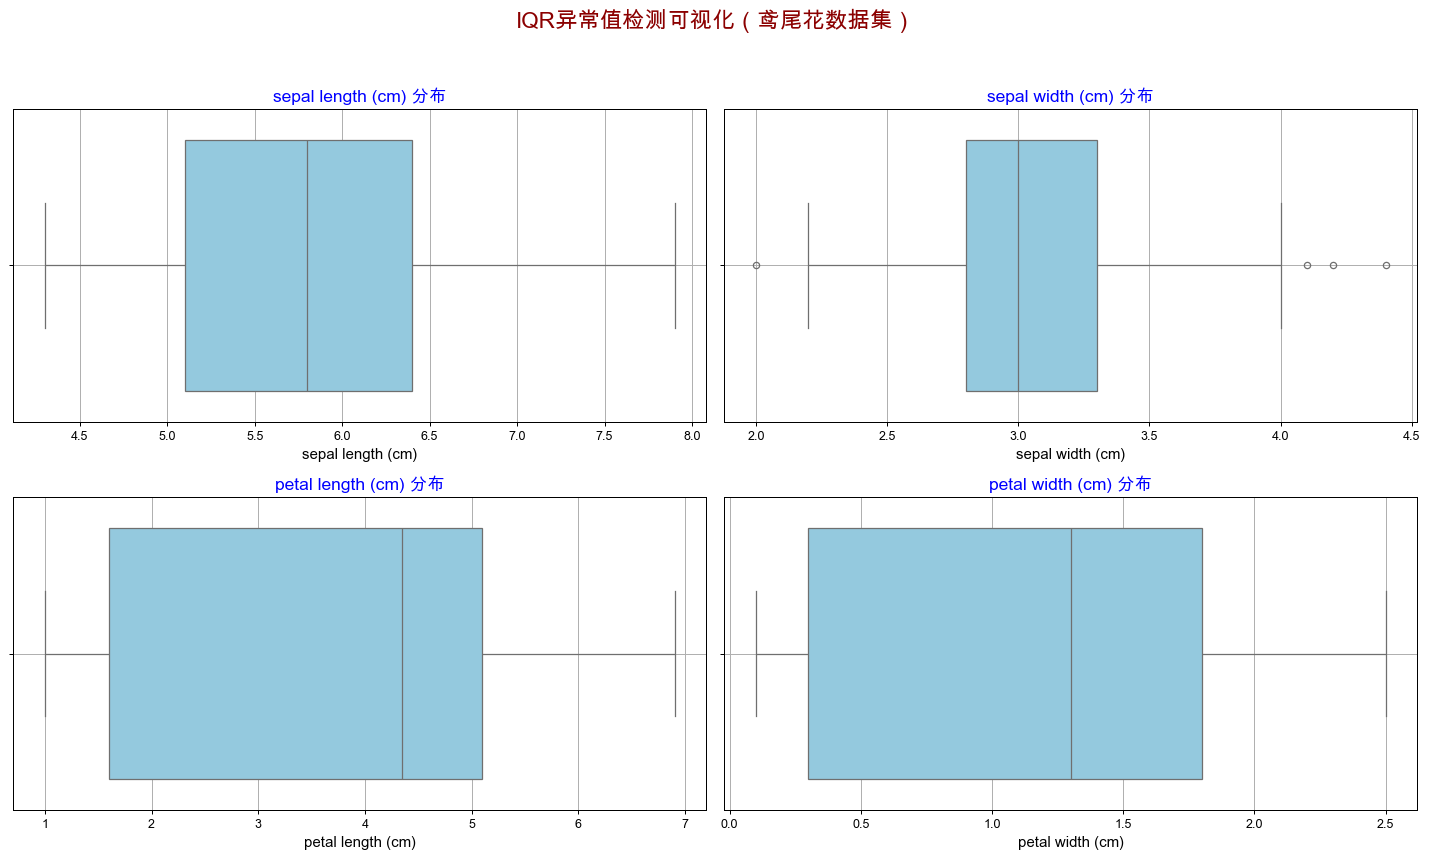

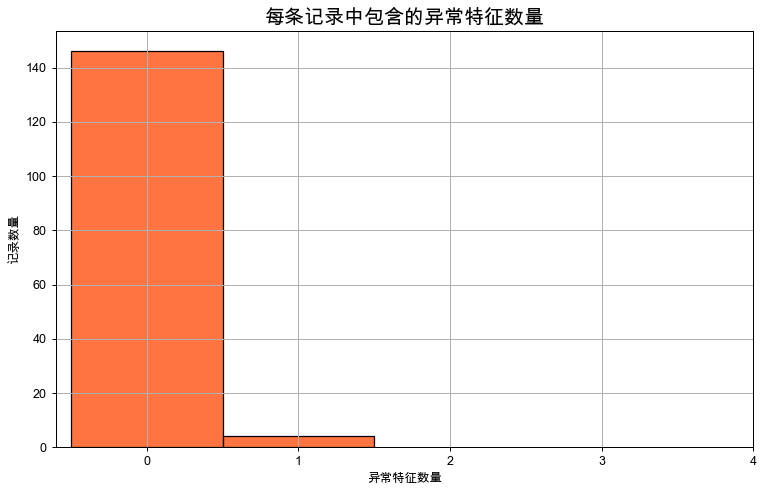

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


# 载入数据
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 用于存储异常值标记
outlier_flags = pd.DataFrame(index=df.index)

# IQR异常值检测
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    return (column < lower_fence) | (column > upper_fence)

# 标记每一列的异常值
for col in df.columns:
    outlier_flags[col] = detect_outliers_iqr(df[col])

# 将异常点数量统计
df["Total Outliers"] = outlier_flags.sum(axis=1)

# 仅保留有异常值的记录
outliers_only = df[df["Total Outliers"] > 0]

# 可视化：原始数据分布 + 异常值标注
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("IQR异常值检测可视化（鸢尾花数据集）", fontsize=18, color='darkred')

for i, col in enumerate(df.columns[:-1]):
    ax = axes[i//2][i%2]
    sns.boxplot(x=df[col], ax=ax, color="skyblue", fliersize=5, flierprops={"marker": "o", "color": "red"})
    ax.set_title(f"{col} 分布", fontsize=14, color='blue')
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 可视化：异常值统计条形图
plt.figure(figsize=(10,6))
sns.histplot(df["Total Outliers"], bins=range(0, 5), discrete=True, color='orangered')
plt.title("每条记录中包含的异常特征数量", fontsize=16)
plt.xlabel("异常特征数量")
plt.ylabel("记录数量")
plt.xticks(range(0, 5))
plt.grid(True)
plt.show()

**Step 1：加载与构建数据集**：

In [3]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

我们使用的是 sklearn 的 `load_iris()`，它提供了 150 行、4列的花卉测量数据。我们将其转为 pandas DataFrame，方便处理。

**Step 2：定义 IQR 异常值检测函数**：

In [4]:
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    return (column < lower_fence) | (column > upper_fence)

这里我们封装了一个标准的 IQR 检测函数。它接受一列数据，返回一个布尔数组，标记每个数是否为异常值。

**Step 3：对每个特征列应用该函数**：

In [5]:
for col in df.columns:
    outlier_flags[col] = detect_outliers_iqr(df[col])

逐列分析，保存标记结果，结果是一个和原数据等长、每列表示一个特征是否异常的布尔矩阵。

**Step 4：统计每一行的异常值数量**：

In [6]:
df["Total Outliers"] = outlier_flags.sum(axis=1)
outliers_only = df[df["Total Outliers"] > 0]

这样可以快速知道：哪一行是有异常的（可能某个花测量值离群）。

**Step 5：可视化分析**：

我们做了两个图：

**Boxplot（箱型图）**：

<Axes: xlabel='petal width (cm)'>

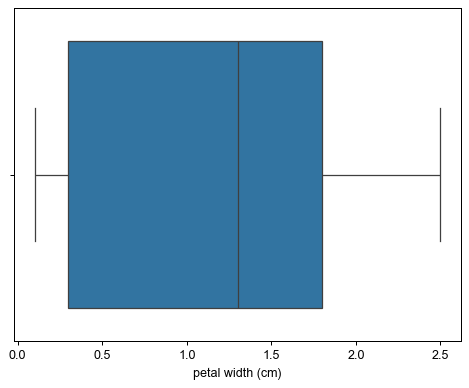

In [7]:
sns.boxplot(x=df[col])

每个特征一个箱线图，异常值以**红色圆点**标记。可以直观看到异常值是否存在、偏移程度、数量等。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

**异常值数量统计图**：

<Axes: xlabel='Total Outliers', ylabel='Count'>

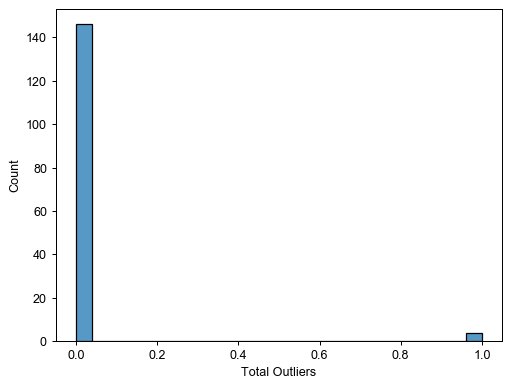

In [8]:
sns.histplot(df["Total Outliers"])

展示每条记录中异常特征的数量分布，大部分记录没有异常，个别记录有 1\~3 个异常。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

### 异常值识别与处理分析

根据图形与数据：

- **sepal width**（萼片宽度）是异常值最多的特征，其箱型图的下胡须外存在不少低值。
- **petal length** 和 **petal width** 也出现少量异常点，尤其是在高端区域。
- 异常值比例不高，说明数据整体质量良好。

我们可以选择：

- 删除这些异常值（影响模型稳定性时）
- 替换或填补（如果不能丢数据）
- 保留分析（如欺诈检测中“离群”就是目标）

### IQR方法的优缺点分析

**优点：**

1. **稳健性高**：使用的是中位数和四分位数，对极端值不敏感，适用于非正态分布数据。
2. **计算简单**：无需复杂数学或迭代，适合大数据量初步清洗。
3. **广泛通用**：适用于各种单位、量纲、数据类型（只要是数值型）。
4. **图像直观**：结合箱型图，易于解释和报告。

**缺点：**

1. **只适用于单变量分析**：无法识别“组合特征”的异常值（如多维离群点）。
2. **无法应对分布极度偏斜的数据**：如果数据严重偏态，四分位间距可能误判。
3. **对离群值位置不敏感**：无法判断是极度异常还是轻微异常。
4. **规则是经验性的**：1.5×IQR 是经验公式，不适合所有情况。

### 什么时候使用 IQR 方法是优选？

**最适合以下场景**：

- **数据为一维或低维的数值型特征**
- **需要快速、稳健处理异常值**
- **数据呈非正态分布或含明显偏态**
- **任务对异常值敏感（如回归、聚类）**

**不适合的情况**：

- 数据是高维、多变量，需要使用如 Mahalanobis 距离或 Isolation Forest。
- 数据有时间序列关系，建议使用时间窗口统计指标。
- 异常值本身是关注点（如欺诈检测），应保留而不是移除。

## 总结

**IQR法是一种简单、有效的异常值检测工具**，尤其适用于小规模、结构清晰的数值型数据清洗过程。在数据预处理的阶段，它可以作为首选方法之一，快速筛选潜在问题数据，帮助提升建模效果。

如需进一步处理高维异常或跨特征异常，实验中可以结合机器学习方法（如 One-Class SVM、LOF、Isolation Forest）进一步建模分析。